# 04 — Experiments

Runs the backbone screen and the five required experiments, then reports the
results with significance tests.

**Every run is the same `ExperimentConfig` with different field values.** There
is one training loop in `src/engine.py`; the arms differ by configuration, never
by code path. Divergent per-variant scripts drift, and a drifted baseline
invalidates every comparison made here.

Training is expensive. Both phases below are **resumable**: `run_matrix` skips
any run already present in `results/summary.csv`, so re-executing a cell after an
interruption costs only the unfinished runs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch

from src import config, engine, experiments, metrics, splits, stats, viz

viz.apply_style()
pd.set_option("display.width", 200)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

c:\Users\nisha\miniconda3\envs\mri-diffuser\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Phase 1 — backbone screen

Four backbones, 6 epochs, identical hierarchical configuration, one seed.

This selects the backbone for Phase 2. It is **not** the backbone comparison
result: six epochs need not rank backbones the way a full run would, and the
write-up should present it as a selection step with that limitation stated.

In [2]:
# Skips anything already in results/summary.csv.
screen = experiments.run_matrix(experiments.screen_configs(epochs=20))

[1/4] screen_mobilenet__mobilenet__seed0
  ep  0  loss 0.6472  val_f1 0.0661  val_bal_acc 0.0739  (588s)  *
  ep  1  loss 0.1211  val_f1 0.8090  val_bal_acc 0.8443  (79s)  *
  ep  2  loss 0.0543  val_f1 0.7846  val_bal_acc 0.8240  (66s)
  ep  3  loss 0.0363  val_f1 0.7980  val_bal_acc 0.8709  (65s)
  ep  4  loss 0.0285  val_f1 0.8365  val_bal_acc 0.8683  (64s)  *
  ep  5  loss 0.0220  val_f1 0.8392  val_bal_acc 0.8570  (64s)  *
  -> test macro_f1 0.8650  bal_acc 0.8968  cross-lineage err 0.0152
[2/4] screen_resnet__resnet__seed0
  ep  0  loss 0.6515  val_f1 0.0488  val_bal_acc 0.0694  (1630s)  *
  ep  1  loss 0.2145  val_f1 0.7728  val_bal_acc 0.7877  (166s)  *
  ep  2  loss 0.0699  val_f1 0.7390  val_bal_acc 0.7686  (194s)
  ep  3  loss 0.0528  val_f1 0.8272  val_bal_acc 0.8487  (191s)  *
  ep  4  loss 0.0413  val_f1 0.8191  val_bal_acc 0.8462  (191s)
  ep  5  loss 0.0346  val_f1 0.8353  val_bal_acc 0.8589  (190s)  *
  -> test macro_f1 0.8501  bal_acc 0.8757  cross-lineage err 0.0162


In [3]:
summary = pd.read_csv(engine.RESULTS_DIR / "summary.csv")
scr = summary[summary.arm.str.startswith("screen_")].copy()

cols = ["backbone", "val_macro_f1", "test_macro_f1", "test_balanced_accuracy",
        "test_cross_lineage_error", "total_minutes"]
scr[cols].sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

,backbone,val_macro_f1,test_macro_f1,test_balanced_accuracy,test_cross_lineage_error,total_minutes
0,vit,0.848880,0.864174,0.878383,0.017297,25.83
1,convnext,0.846055,0.867614,0.895203,0.015695,89.66
2,mobilenet,0.839168,0.864981,0.896808,0.015215,17.99
3,resnet,0.835264,0.850127,0.875708,0.016176,44.87


In [4]:
# Selection is on validation macro F1 - never test, which stays untouched
# until the final evaluation, and never accuracy.
BEST_BACKBONE = scr.sort_values("val_macro_f1", ascending=False).iloc[0]["backbone"]
print(f"selected backbone: {BEST_BACKBONE}")

selected backbone: vit


## Phase 2 — the five required experiments

Four distinct configurations at three seeds each = 12 runs, all on the selected
backbone with identical splits.


In [5]:
main = experiments.run_matrix(
    experiments.main_configs(backbone=BEST_BACKBONE, epochs=50)
)

[1/12] flat_baseline__vit__seed0
  ep  0  loss 0.5970  val_f1 0.1758  val_bal_acc 0.1766  (495s)  *
  ep  1  loss 0.1673  val_f1 0.6890  val_bal_acc 0.7281  (184s)  *
  ep  2  loss 0.0853  val_f1 0.7336  val_bal_acc 0.8024  (183s)  *
  ep  3  loss 0.0677  val_f1 0.7940  val_bal_acc 0.8215  (122s)  *
  ep  4  loss 0.0609  val_f1 0.7758  val_bal_acc 0.8127  (75s)
  ep  5  loss 0.0542  val_f1 0.7815  val_bal_acc 0.7782  (94s)
  ep  6  loss 0.0513  val_f1 0.7754  val_bal_acc 0.8260  (70s)
  ep  7  loss 0.0488  val_f1 0.8111  val_bal_acc 0.8364  (71s)  *
  ep  8  loss 0.0453  val_f1 0.7532  val_bal_acc 0.8415  (73s)
  ep  9  loss 0.0436  val_f1 0.7936  val_bal_acc 0.8310  (81s)
  ep 10  loss 0.0439  val_f1 0.8030  val_bal_acc 0.8449  (72s)
  ep 11  loss 0.0390  val_f1 0.8060  val_bal_acc 0.8414  (72s)
  ep 12  loss 0.0381  val_f1 0.7878  val_bal_acc 0.8238  (73s)
  ep 13  loss 0.0368  val_f1 0.8026  val_bal_acc 0.8555  (73s)
  early stop at epoch 13 (no val macro-F1 gain for 6 epochs)
  -> 

In [6]:
summary = pd.read_csv(engine.RESULTS_DIR / "summary.csv")
runs = summary[~summary.arm.str.startswith(("screen_", "smoke_"))].copy()
print(f"{len(runs)} runs across {runs.arm.nunique()} arms and {runs.seed.nunique()} seeds")

arm_stats = stats.arm_summary(runs)
arm_stats.round(4)

12 runs across 4 arms and 3 seeds


,arm,n_seeds,test_macro_f1_mean,test_macro_f1_std,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_accuracy_mean,test_accuracy_std,test_minority_macro_f1_mean,test_minority_macro_f1_std,test_cross_lineage_error_mean,test_cross_lineage_error_std
1,hierarchical,3,0.8532,0.0141,0.8599,0.0175,0.9411,0.0039,0.7909,0.0255,0.0149,0.0014
0,flat_baseline,3,0.8447,0.0262,0.8694,0.0208,0.9296,0.0152,0.8191,0.0310,0.0202,0.0036
2,no_imbalance,3,0.8238,0.0115,0.8155,0.0175,0.9303,0.0042,0.7106,0.0363,0.0209,0.0038
3,stain_norm,3,0.8235,0.0207,0.8389,0.0078,0.9251,0.0112,0.7582,0.0179,0.0239,0.0074


### Headline comparison

Macro F1 and balanced accuracy are the headline metrics, not accuracy. At 260:1
imbalance a model that ignores reactive lymphocytes entirely loses ~0.08%
accuracy, so accuracy cannot see the behaviour this dissertation is about.

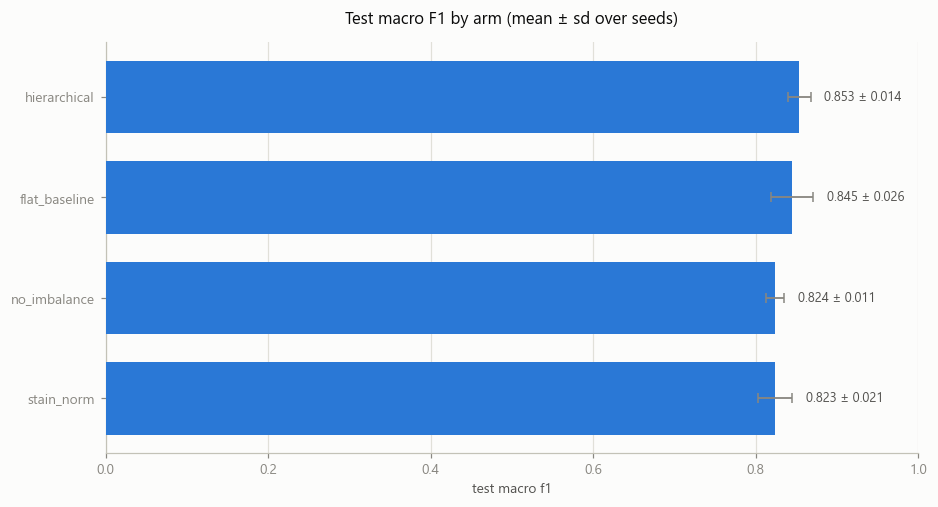

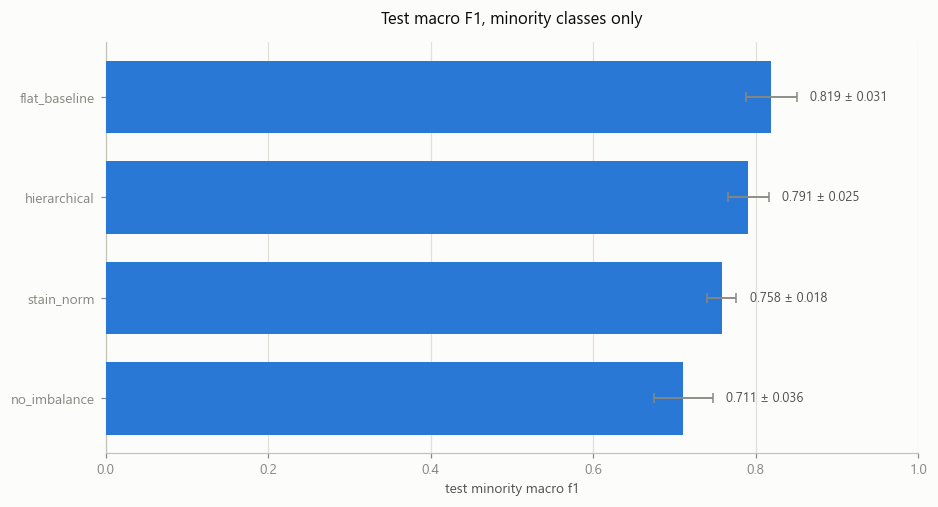

In [7]:
f = viz.arm_comparison(arm_stats, metric="test_macro_f1",
                       title="Test macro F1 by arm (mean ± sd over seeds)")
f.savefig(config.ARTIFACT_DIR / "arm_macro_f1.png")

f = viz.arm_comparison(arm_stats, metric="test_minority_macro_f1",
                       title="Test macro F1, minority classes only")
f.savefig(config.ARTIFACT_DIR / "arm_minority_f1.png")

### Hierarchical error composition

The figure that carries the hierarchical claim. Errors are split into
within-lineage (clinically mild — typically adjacent maturation stages) and
cross-lineage (clinically severe).

A lineage-aware model should shrink the cross-lineage segment specifically,
moving error toward the milder kind. That shift can happen with little or no
change in overall accuracy, which is exactly why accuracy is the wrong headline.

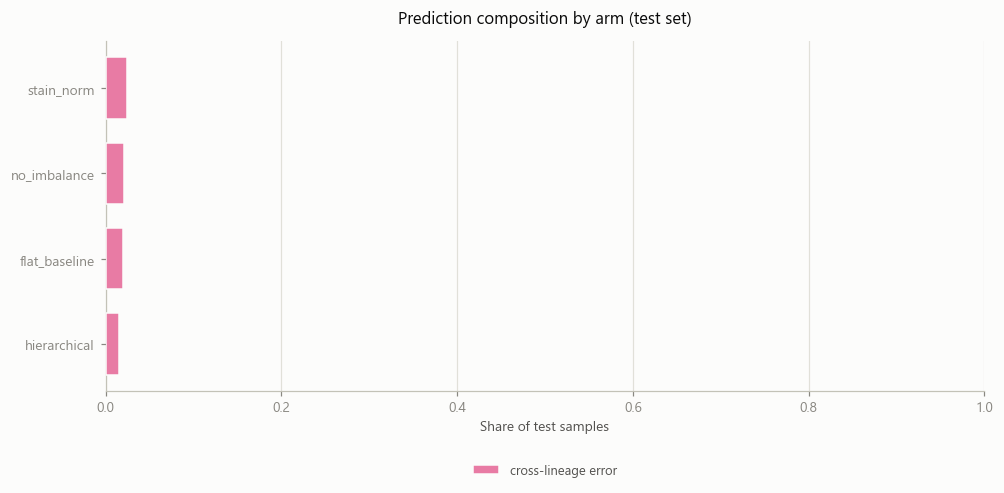

In [8]:
f = viz.error_composition(arm_stats,
                          title="Prediction composition by arm (test set)")
f.savefig(config.ARTIFACT_DIR / "error_composition.png")

### Significance

Paired t-tests across seeds against the flat baseline, with Cohen's d.

Read these with the sample size in mind: three seeds gives 2 degrees of freedom
and very little power. A non-significant result here is **weak evidence of no
difference, not evidence of no difference**. Effect sizes and per-seed values are
reported alongside so the conclusion never rests on the p-value alone.

In [9]:
comp = stats.comparison_table(runs, baseline="flat_baseline", metric="test_macro_f1")
for _, r in comp.iterrows():
    print(stats.format_result(r.to_dict()))
print()
comp.round(4)

hierarchical vs flat_baseline on test_macro_f1: 0.8532 vs 0.8447 (diff +0.0085), t(2)=0.46, p=0.6886 [not significant], d=0.27, n=3
no_imbalance vs flat_baseline on test_macro_f1: 0.8238 vs 0.8447 (diff -0.0209), t(2)=-0.97, p=0.4355 [not significant], d=-0.56, n=3
stain_norm vs flat_baseline on test_macro_f1: 0.8235 vs 0.8447 (diff -0.0212), t(2)=-0.79, p=0.5116 [not significant], d=-0.46, n=3



,arm_a,arm_b,metric,n_pairs,mean_a,std_a,mean_b,std_b,mean_diff,t,p_value,cohens_d
0,hierarchical,flat_baseline,test_macro_f1,3,0.8532,0.0141,0.8447,0.0262,0.0085,0.4635,0.6886,0.2676
1,no_imbalance,flat_baseline,test_macro_f1,3,0.8238,0.0115,0.8447,0.0262,-0.0209,-0.9672,0.4355,-0.5584
2,stain_norm,flat_baseline,test_macro_f1,3,0.8235,0.0207,0.8447,0.0262,-0.0212,-0.7916,0.5116,-0.4570


In [10]:
# The same tests on the minority-class metric and on cross-lineage error -
# the two quantities the dissertation actually argues about.
for metric in ("test_minority_macro_f1", "test_cross_lineage_error",
               "test_balanced_accuracy"):
    print(f"--- {metric} ---")
    for _, r in stats.comparison_table(runs, "flat_baseline", metric).iterrows():
        print("  " + stats.format_result(r.to_dict()))
    print()

--- test_minority_macro_f1 ---
  hierarchical vs flat_baseline on test_minority_macro_f1: 0.7909 vs 0.8191 (diff -0.0282), t(2)=-1.19, p=0.3553 [not significant], d=-0.69, n=3
  no_imbalance vs flat_baseline on test_minority_macro_f1: 0.7106 vs 0.8191 (diff -0.1085), t(2)=-2.82, p=0.1058 [not significant], d=-1.63, n=3
  stain_norm vs flat_baseline on test_minority_macro_f1: 0.7582 vs 0.8191 (diff -0.0609), t(2)=-2.16, p=0.1632 [not significant], d=-1.25, n=3

--- test_cross_lineage_error ---
  hierarchical vs flat_baseline on test_cross_lineage_error: 0.0149 vs 0.0202 (diff -0.0053), t(2)=-2.19, p=0.1595 [not significant], d=-1.27, n=3
  no_imbalance vs flat_baseline on test_cross_lineage_error: 0.0209 vs 0.0202 (diff +0.0007), t(2)=0.18, p=0.8751 [not significant], d=0.10, n=3
  stain_norm vs flat_baseline on test_cross_lineage_error: 0.0239 vs 0.0202 (diff +0.0037), t(2)=0.60, p=0.6094 [not significant], d=0.35, n=3

--- test_balanced_accuracy ---
  hierarchical vs flat_baseline on 

### Per-seed values

Shown in full rather than summarised, so the spread behind each mean is visible
and the reader can judge the t-tests for themselves.

In [11]:
runs.pivot_table(index="arm", columns="seed", values="test_macro_f1").round(4)

seed,0,1,2
arm,,,
flat_baseline,0.8378,0.8227,0.8737
hierarchical,0.8695,0.8443,0.8459
no_imbalance,0.8298,0.8311,0.8106
stain_norm,0.8350,0.8358,0.7996


### Training curves

Loss components, the selection metric, and how the error split evolves. If the
hierarchy is contributing, the lineage and consistency curves must actually move
— a flat consistency curve would mean the term is inert.

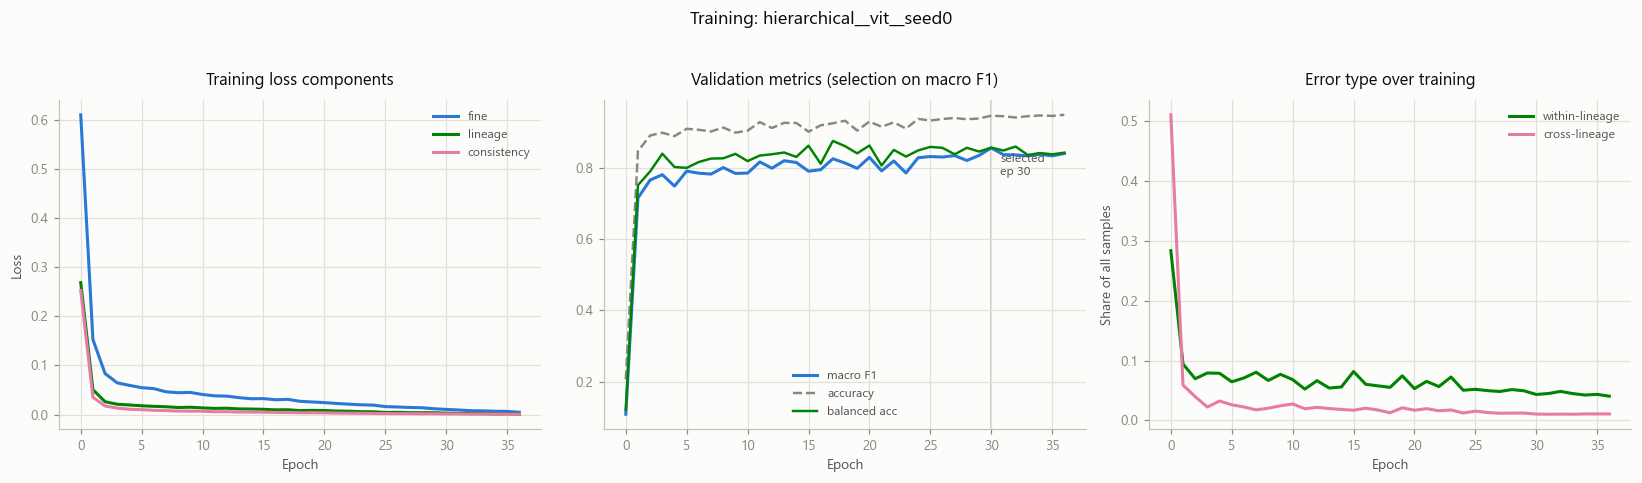

In [12]:
run_id = runs[(runs.arm == "hierarchical") & (runs.seed == 0)].iloc[0]["run_id"]
hist = pd.read_csv(engine.RESULTS_DIR / f"history_{run_id}.csv")

f = viz.training_curves(hist, title=f"Training: {run_id}")
f.savefig(config.ARTIFACT_DIR / "training_curves.png")

---

## Summary

Results are written to `results/summary.csv` (one row per run) and
`results/history_*.csv` (per-epoch). Notebook 05 does the detailed evaluation:
confusion matrices, per-class behaviour, and Grad-CAM.